In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import os

from mossbauer_analysis.mossbauer_theory import CobaltRhodium, CobaltFe, KFeCy, alphaFe, Mossbauer    #import classes for sources, absorbers, and the mossbauer transmission spectrumfrom mossbauer_analysis.fit_functions import linear,single_peak_lorentzian_poly1, single_peak_lorentzian_poly2, six_peak_lorentzian_poly1,six_peak_lorentzian_poly2,six_peak_lorentzian_poly3, six_peak_lorentzian_poly5
from mossbauer_analysis.ironanalytics_load import read_ironanalytics_data, print_ironanalytics_metadata 
import mossbauer_analysis.utils as u
from mossbauer_analysis.ironanalytics_analyze import fit_and_calibrate
from mossbauer_analysis.fit_functions import linear, poly2,poly5, single_peak_lorentzian_poly1, single_peak_lorentzian_poly2, six_peak_lorentzian_poly1,six_peak_lorentzian_poly2, six_peak_lorentzian_poly5



In [8]:
dir = 'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/calbration_spectra'
id = 'A00043'
print_ironanalytics_metadata(dir)
dat = read_ironanalytics_data(dir, id, offset = -3)

ID: A00043,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: alpha25um_28OCT24_reference
ID: A00047,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: fe57_06NOV24_third_deposition
ID: A00048,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: fe57_10NOV24_fourth_deposition
ID: A00049,	 v_max: 2,	  det: 70,	 10,	 1551,	 3278,	 Description: FeCy_single
ID: A00051,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: fe57_08DEC24_fifth_deposition
ID: A00056,	 v_max: 10,	  det: 70,	 10,	 1551,	 3278,	 Description: fe57_07JAN25_sixth_deposition
ID: A00057,	 v_max: 2,	  det: 70,	 90,	 1006,	 3248,	 Description: FeCy_detector_test
ID: A00068,	 v_max: 2,	  det: 85,	 0,	 912,	 3002,	 Description: FeCy_newsource
ID: A00070,	 v_max: 2,	  det: 70,	 10,	 1556,	 3277,	 Description: FeCy_newsource_oldsettings_2
ID: A00085,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: fe57_31JAN25_seventh_deposition_take2
ID: A00104,	 v_max: 6,	  det: 70,	 10,	 1556,	 3277,	 Descriptio

## Anlalyze single file

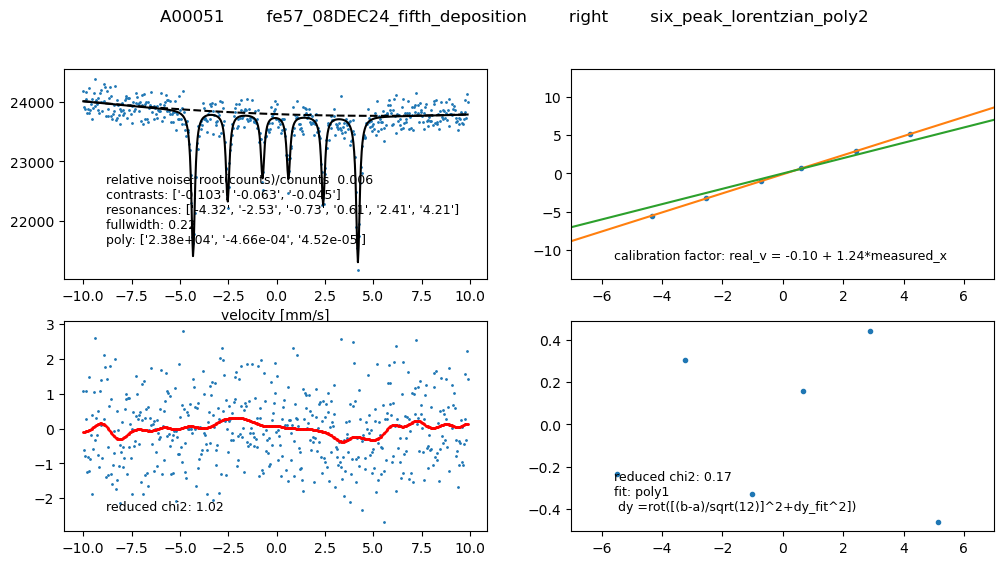

In [11]:


fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e5, 1e2, 1e1],  
            }


params = {  'directory':  'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/calbration_spectra',
            'id': 'A00051',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)

## Reference Absorbers: 

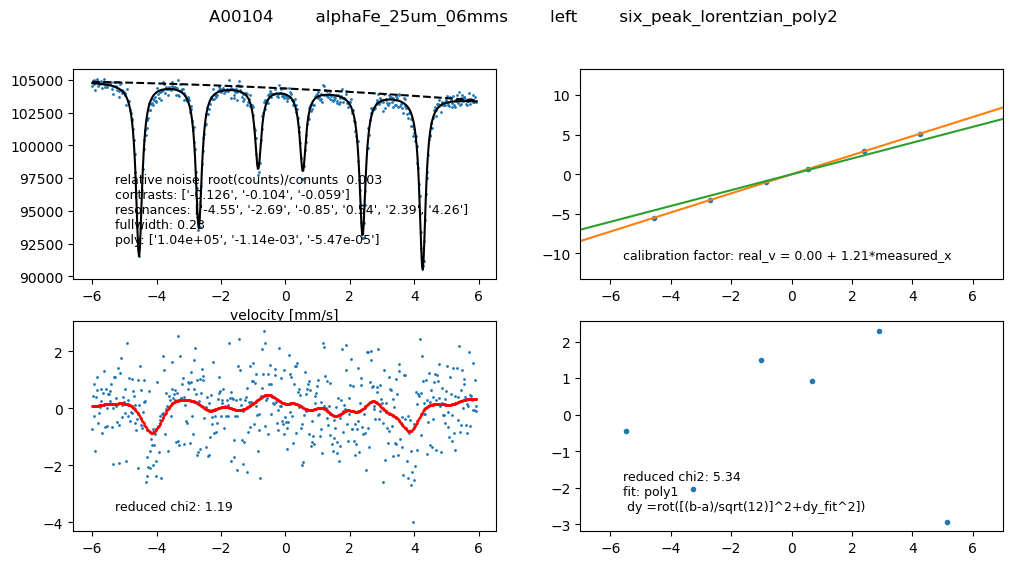

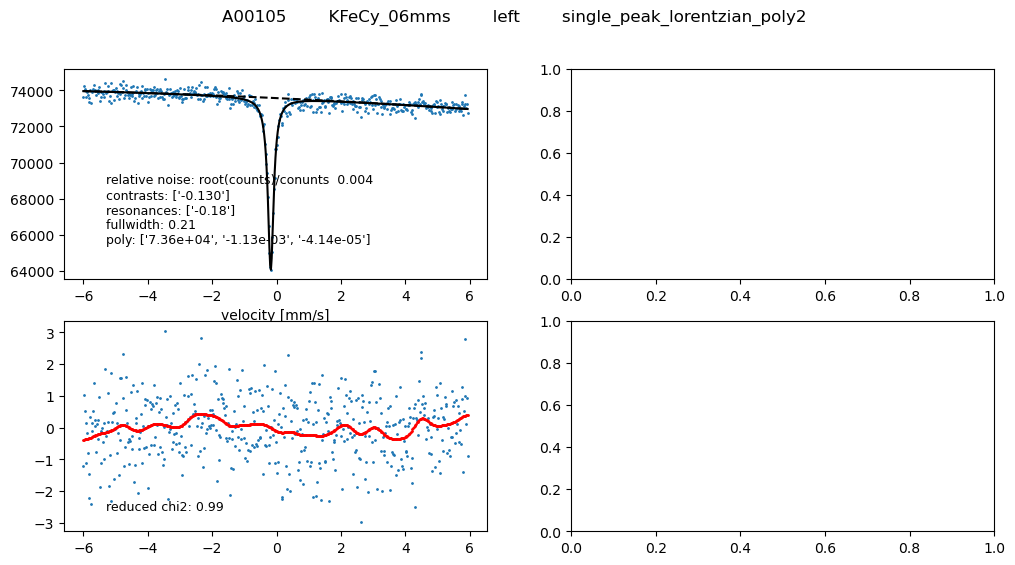

In [15]:

fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e5, 1e2, 1e1],  
            }

params = {  'directory': 'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/calbration_spectra',
            'id': 'A00104',
            'offset': -3,
            'side': 'left',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)


# potrassium ferrocianide

fit_guess = {
        'contrasts': -0.2,
        'resonances': -0.078,
        'fullwidth': 0.2,
        'poly': [1e5, 1e-3, 1e-5],  
        }


params = {  'directory': 'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/calbration_spectra',
        'id': 'A00105',
        'offset': -3,
        'side': 'left',
        'npeaks': 6,
        'fitfunction': single_peak_lorentzian_poly2,
        'calibration_resonances': -0.78,
        
} 

params_out = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = False, plot = True)

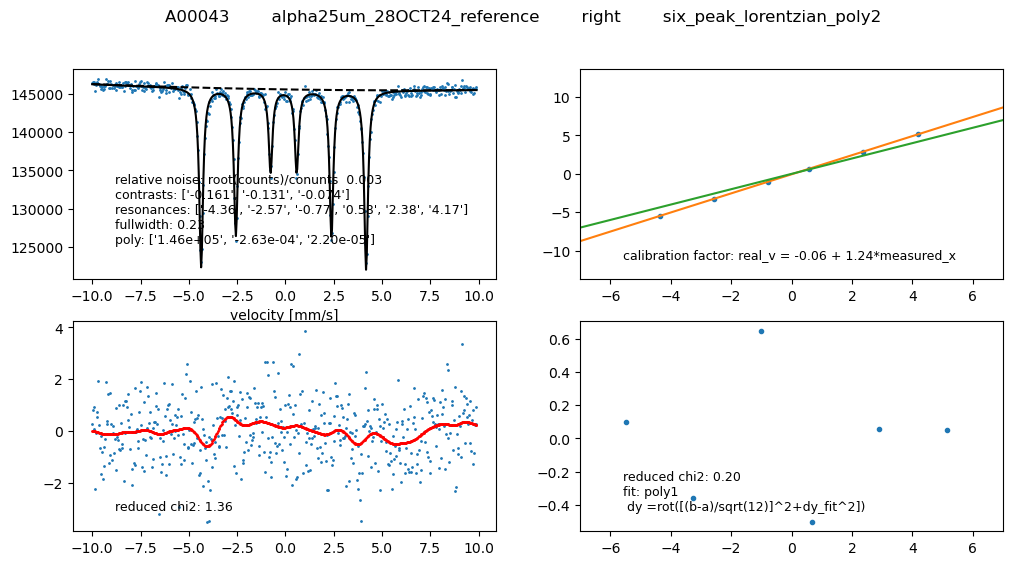

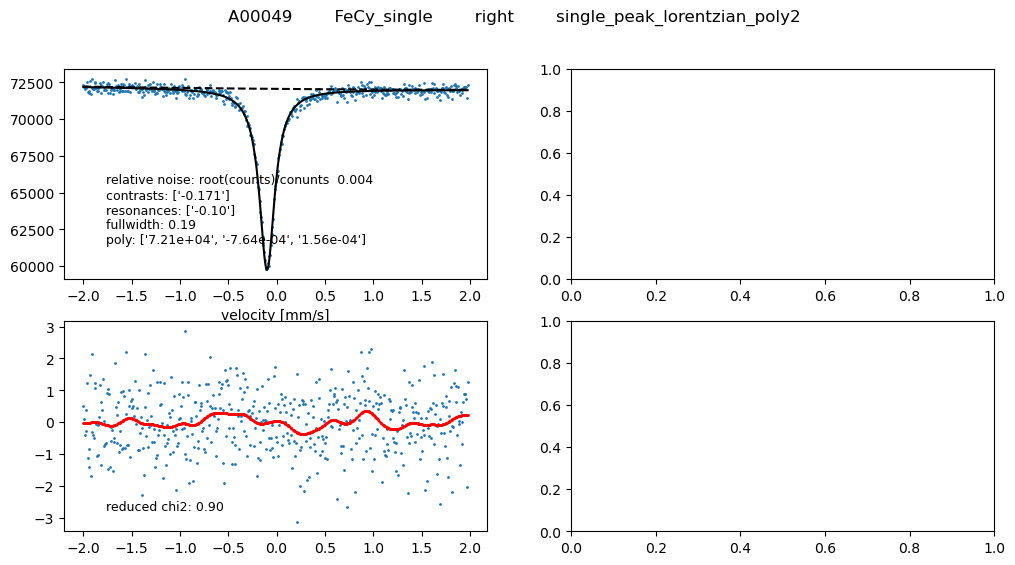

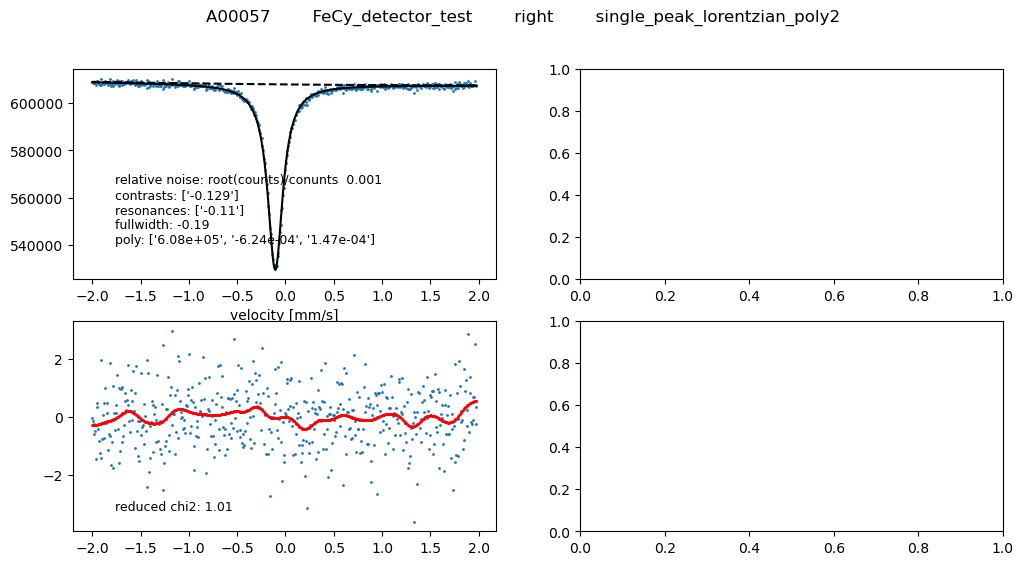

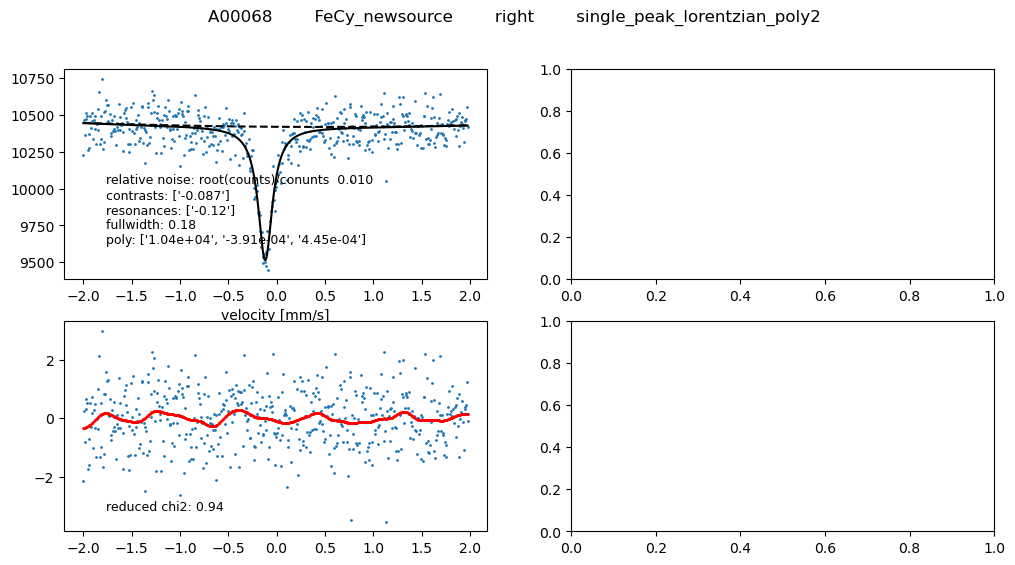

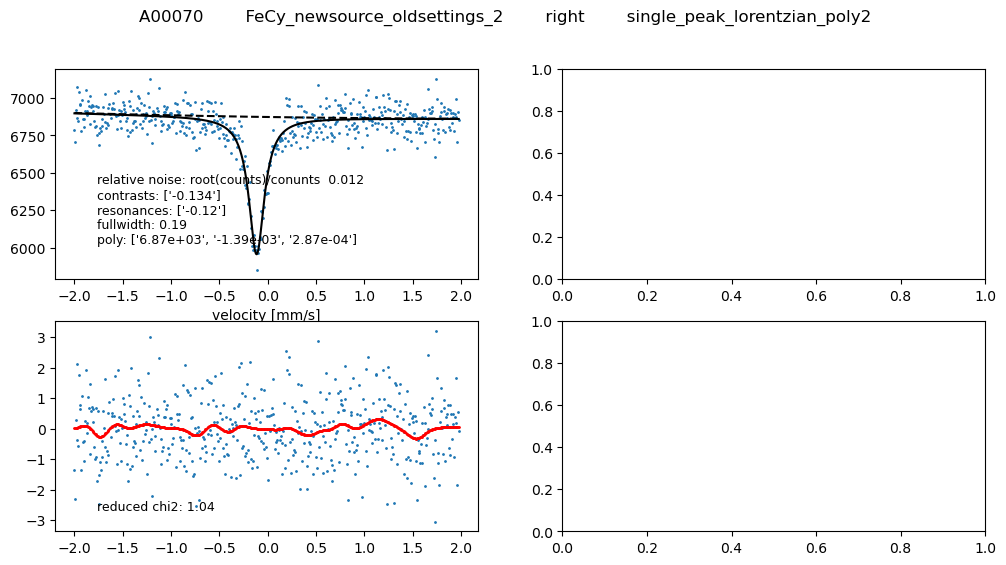

In [16]:


fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e5, 1e2, 1e1],  
            }


params = {  'directory': 'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/calbration_spectra',
            'id': 'A00043',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 

params = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)


# potrassium ferrocianide

fit_guess = {
        'contrasts': -0.2,
        'resonances': -0.078,
        'fullwidth': 0.2,
        'poly': [1e5, 1e-3, 1e-5],  
        }


params = {  'directory': 'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/calbration_spectra',
        'id': 'A00049',
        'offset': -3,
        'side': 'right',
        'npeaks': 6,
        'fitfunction': single_peak_lorentzian_poly2,
        'calibration_resonances': -0.78,
        
} 


for id in ['A00049', 'A00057', 'A00068', 'A00070']:
        params['id'] = id
        params_out = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = False, plot = True)

## The various Fe57 depositions, right:

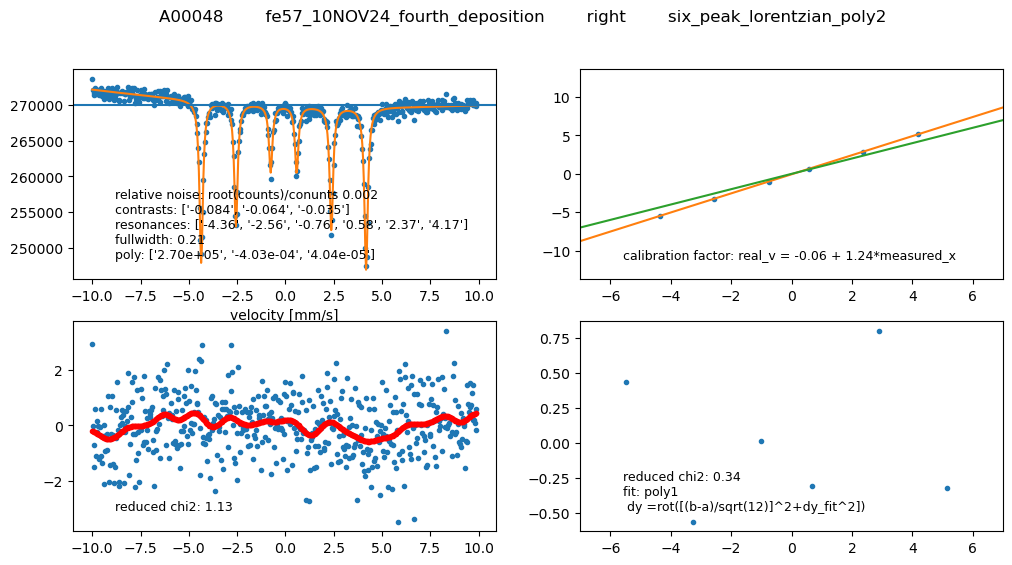

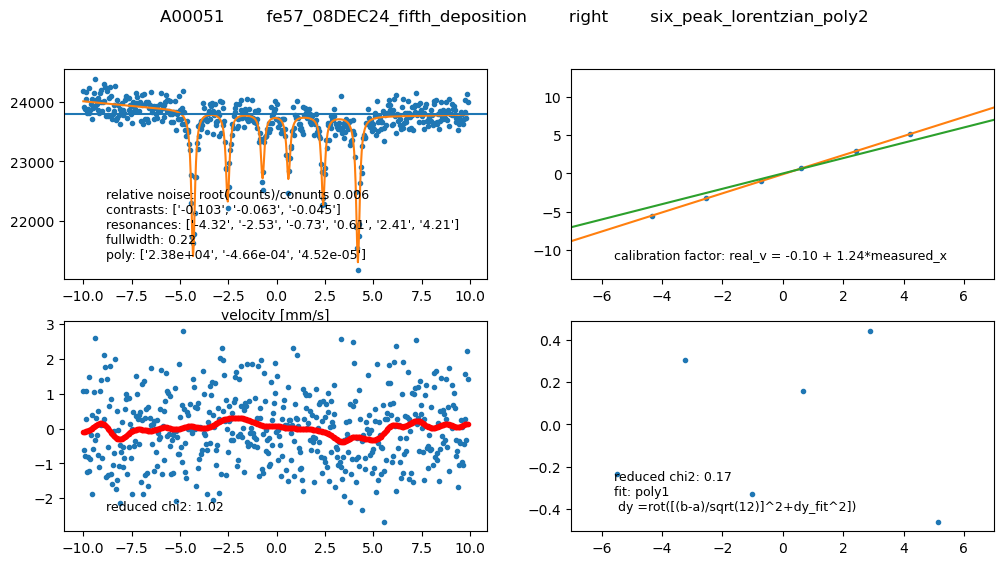

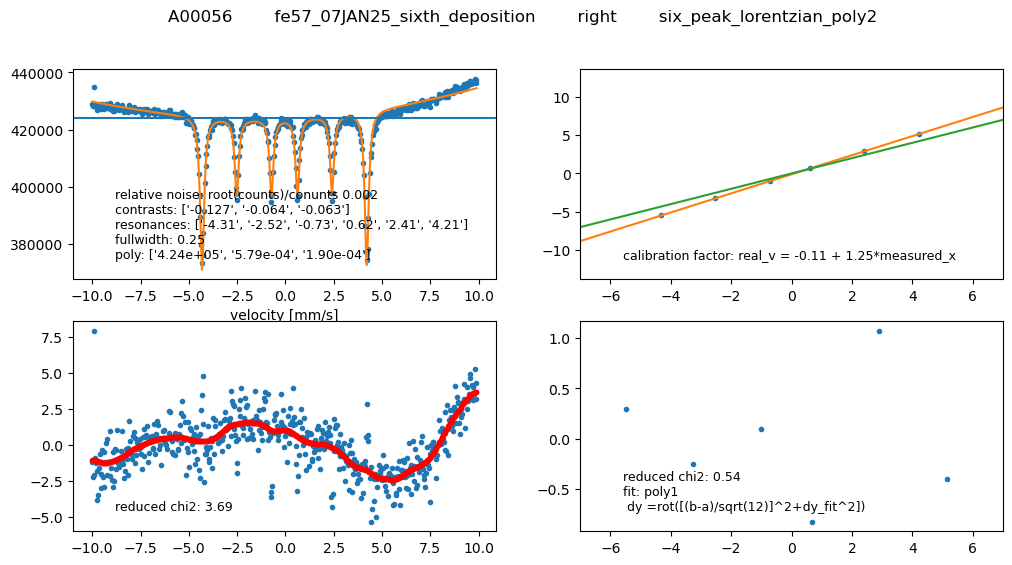

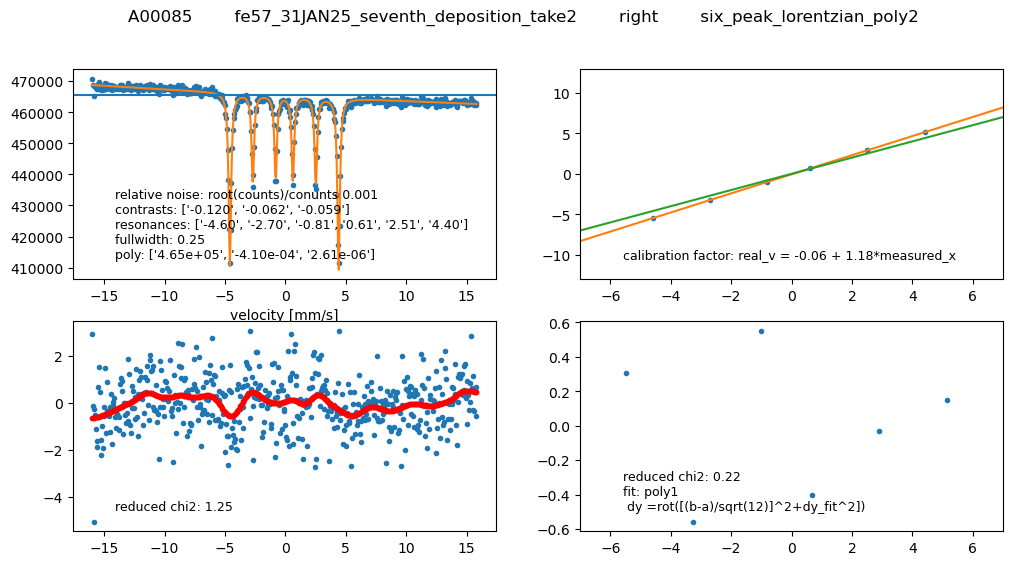

In [4]:

fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e6, 1e2, 1e1],  
            }


params = {  'directory': 'C:/Users/magrini/Documents/programming/mossbauer_theory/data/SAW_spectra/calbration_spectra',
            'id': 'A00051',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 


for id in ['A00048', 'A00051', 'A00056', 'A00085']:
        params['id'] = id
        params_out = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)


## The various Fe57 depositions, left:

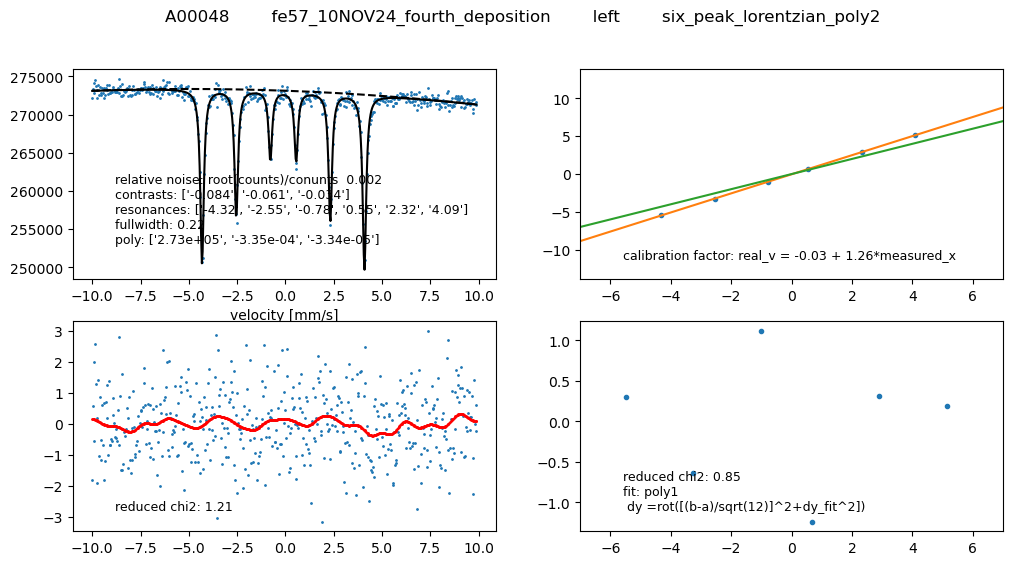

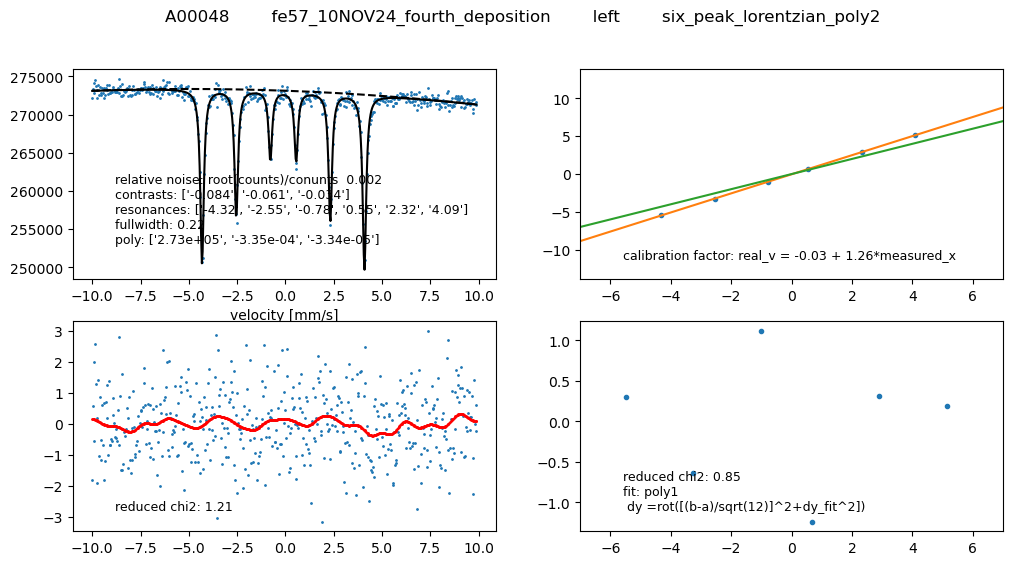

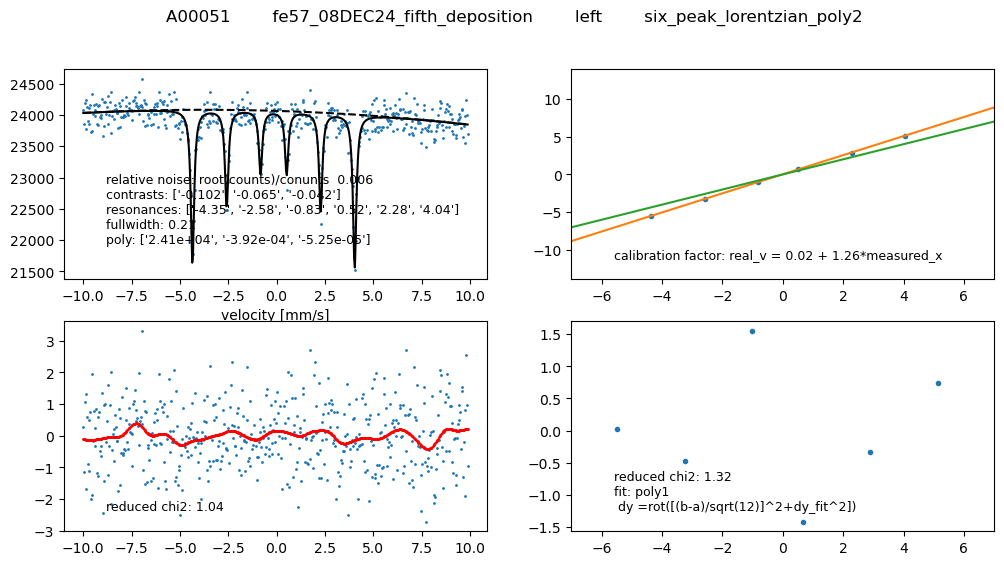

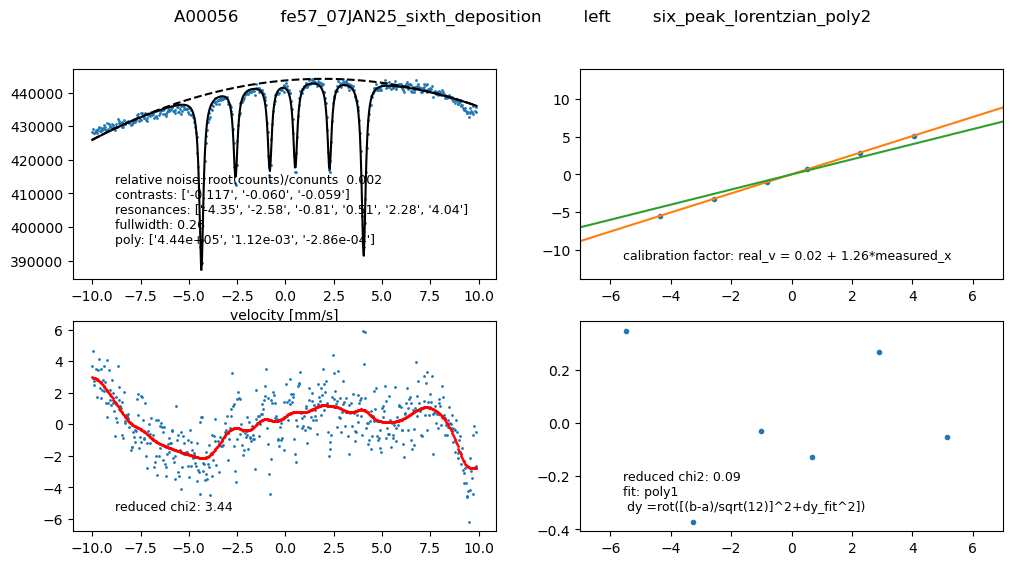

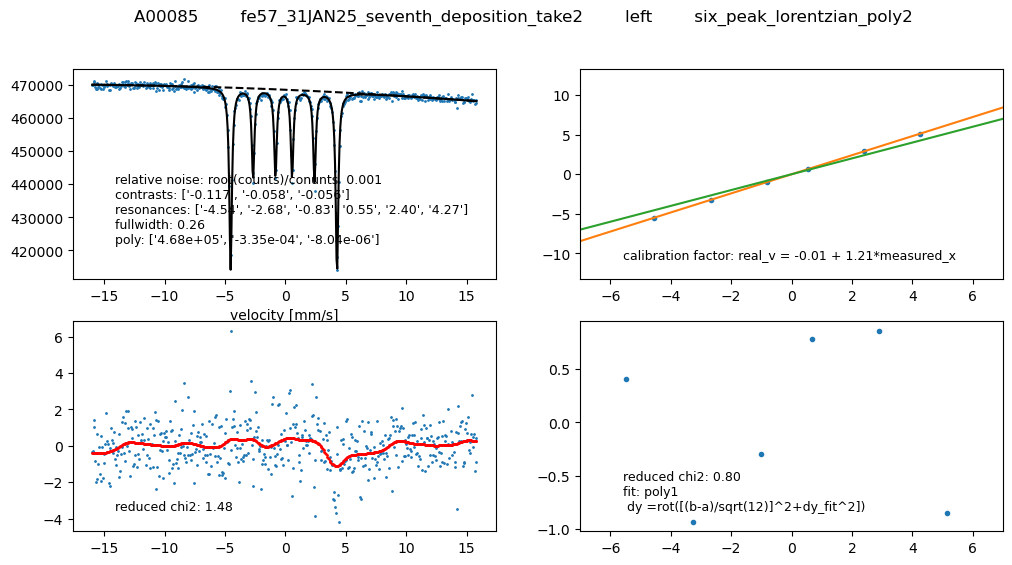

In [18]:

fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e6, 1e2, 1e1],  
            }


params = {  'directory':  'C:/Users/magrini/Documents/programming/mossbauer_analysis/data/calbration_spectra',
            'id': 'A00051',
            'offset': -3,
            'side': 'left',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 


for id in ['A00048', 'A00048', 'A00051', 'A00056', 'A00085']:
        params['id'] = id
        params_out = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)


## The various Fe57 depositions, folded:

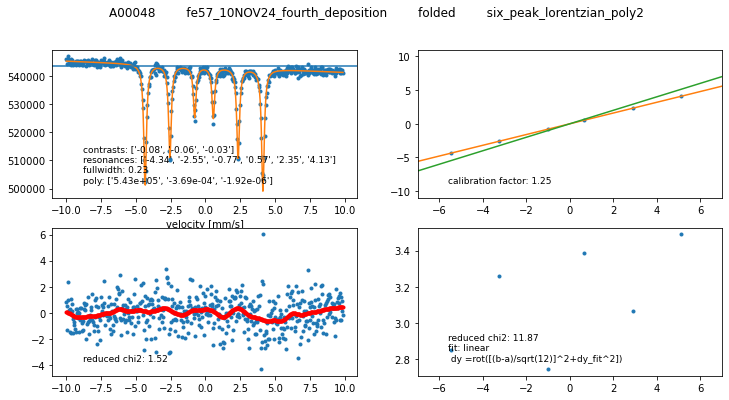

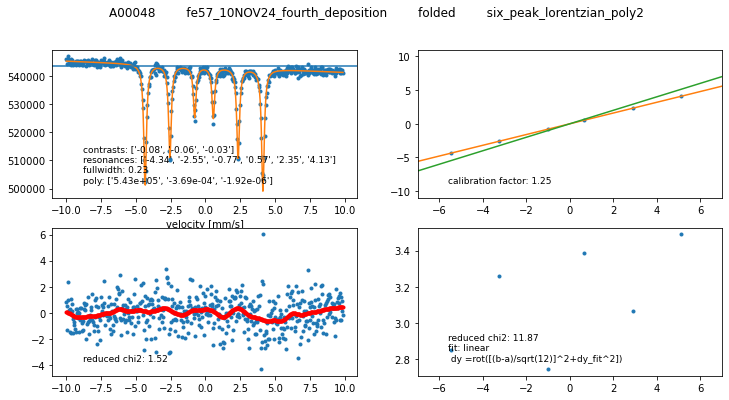

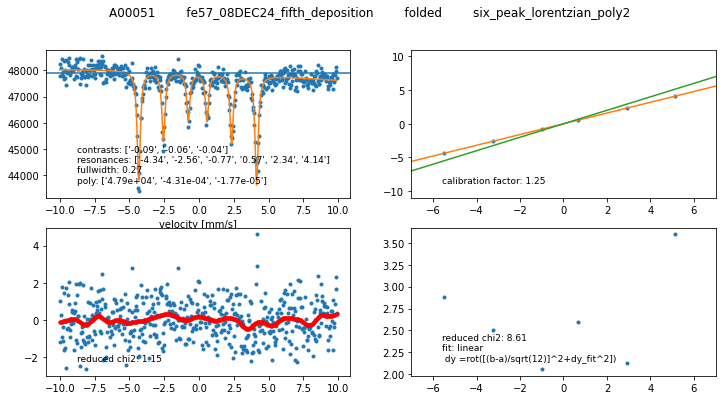

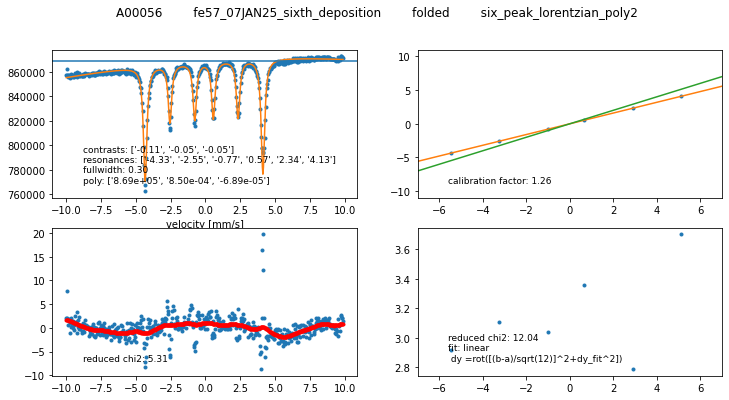

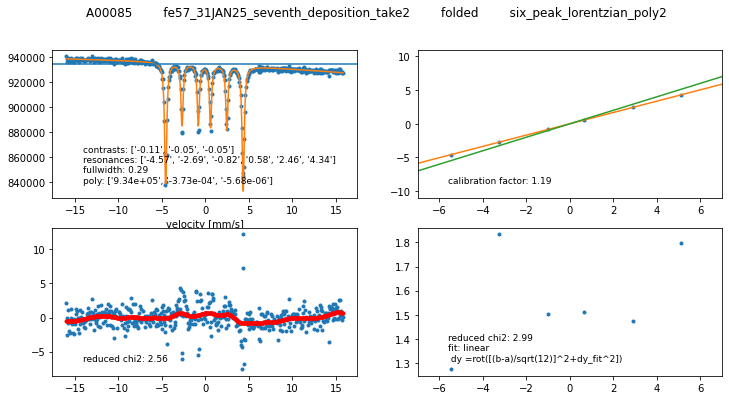

In [ ]:

fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e6, 1e2, 1e1],  
            }


params = {  'directory':  'C:/Users/magrini/Documents/programming/mossbauer_theory/data/SAW_spectra/calbration_spectra',
            'id': 'A00051',
            'offset': -3,
            'side': 'folded',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly2,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 


for id in ['A00048', 'A00048', 'A00051', 'A00056', 'A00085']:
        params['id'] = id
        params_out = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)


## Now all the SAW measurements

In [9]:
dir ='C:/Users/magrini/Documents/programming/mossbauer_theory/data/SAW_spectra/saw_spectra_16mms/'
print_ironanalytics_metadata(dir)

ID: A00087,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m10dBm_glued_W_16mmps
ID: A00088,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m100dBm_glued_W_16mmps
ID: A00089,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m10dBm_glued_W_16mmps
ID: A00090,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m07dBm_glued_W_16mmps
ID: A00091,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m05dBm_glued_W_16mmps
ID: A00092,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m03dBm_glued_W_16mmps
ID: A00093,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m05dBm_glued_W_16mmps
ID: A00094,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m07dBm_glued_W_16mmps
ID: A00095,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Description: AGM_TN02_SN01_m09dBm_glued_W_16mmps
ID: A00096,	 v_max: 16,	  det: 70,	 10,	 1556,	 3277,	 Descript

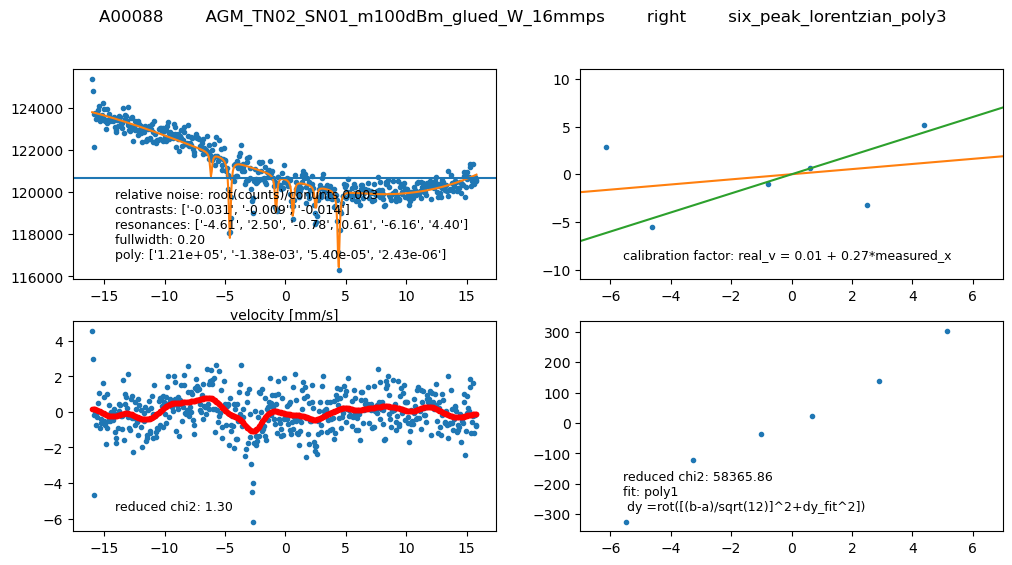

In [7]:
# import data:

fit_guess = {
            'contrasts': [-1e2, -1e2, -1e2],
            'resonances': [-4.32,-2.55,-0.78,0.55,2.31,4.09],
            'fullwidth': 0.2,
            'poly': [3e6, 1e2, 1e1,1e-2],  
            }


params = {  'directory':  'C:/Users/magrini/Documents/programming/mossbauer_theory/data/SAW_spectra/saw_spectra_16mms/',
            'id': 'A00051',
            'offset': -3,
            'side': 'right',
            'npeaks': 6,
            'fitfunction': six_peak_lorentzian_poly3,
            'calibration_resonances': [-5.48, -3.25, -1.01, 0.66, 2.90, 5.13],
        
        } 


#for id in ['A00087', 'A00088', 'A00089', 'A00090', 'A00091', 'A00092', 'A00093', 'A00094', 'A00095', 'A00096', 'A00097', 'A00098', 'A00101', 'A00102']:
for id in ['A00088']:
        params['id'] = id
        params_out = fit_and_calibrate(params = params , fit_guess = fit_guess, calibrate_resonances = True, plot = True)


(0.15426697235454379,
 0.1541001378201782,
 109.18415990610202,
 0.9949883959346847)

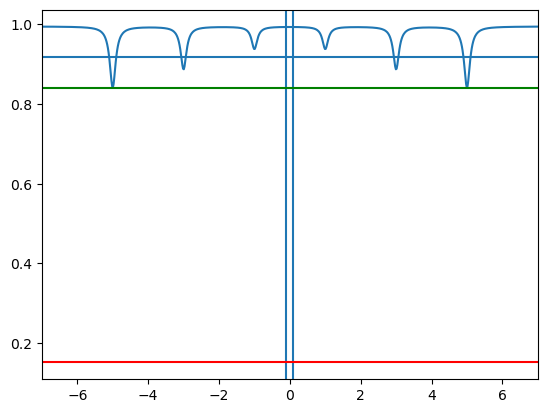

In [3]:
source = CobaltRhodium()

absorber = alphaFe()
absorber.thickness_m = 100e-9  # thickness in m
absorber.abundance = 0.96
absorber.update_params()

moss = Mossbauer(source, absorber)

v = np.linspace(-10,10,1000)
t = moss.total_transmission_rate1(v)
norm = moss.source.mossbauer_photon_rate


plt.plot(v, t/norm, label = 'Fe')

plt.axhline((1-((t.max()-t.min())/2/t.max()))*moss.non_resonant_attenuation())
plt.axvline(-(source.Gamma + absorber.Gamma)/2)
plt.axvline((source.Gamma + absorber.Gamma)/2)


plt.axhline(moss.nonresonant_transmission_rate()/norm, color = 'r', label = 'non-resonant transmission')
plt.axhline((1 - source.fs*moss.epsilon(absorber.thickness_normalized*3/12))*moss.non_resonant_attenuation(),color = 'g')



#plt.ylim(0,1)
plt.xlim(-7,7)

B = 0.#80
vis = moss.epsilon(absorber.thickness_normalized*3/12)*source.fs*(1-B)
vis, (t.max()-t.min())/(t.max()), source.mossbauer_photon_rate/1e6, moss.non_resonant_attenuation()



(0.24343782594613275,
 0.1942900203891657,
 115.20316534892626,
 0.9654418277053305)

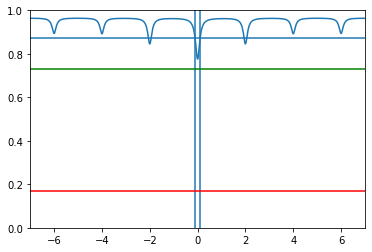

In [101]:
source = CobaltFe()
#source = CobaltRhodium()

absorber = alphaFe()
absorber.thickness_m = 700e-9  # thickness in m
absorber.abundance = 0.25
absorber.update_params()

moss = Mossbauer(source, absorber)

v = np.linspace(-10,10,1000)
t = moss.total_transmission_rate1(v)
norm = moss.source.mossbauer_photon_rate


plt.plot(v, t/norm, label = 'Fe')

plt.axhline((1-((t.max()-t.min())/2/t.max()))*moss.non_resonant_attenuation())
plt.axvline(-(source.Gamma + absorber.Gamma)/2)
plt.axvline((source.Gamma + absorber.Gamma)/2)

plt.axhline((1 - source.fs)*moss.non_resonant_attenuation(),color = 'r')
plt.axhline((1 - source.fs*moss.epsilon(absorber.thickness_normalized*3/12))*moss.non_resonant_attenuation(),color = 'g')



plt.ylim(0,1)
plt.xlim(-7,7)


vis = moss.epsilon(absorber.thickness_normalized*3/12)*source.fs
vis, (t.max()-t.min())/(t.max()), source.mossbauer_photon_rate/1e6, moss.non_resonant_attenuation()

0.18002057495577392

In [90]:
nr_t_rate = moss.nonresonant_transmission_rate()/norm
h= (1 - source.fs*moss.epsilon(absorber.thickness_normalized*3/12))*moss.non_resonant_attenuation()

nr_t_rate*100, h*100, 1-(nr_t_rate+h)
moss.epsilon(absorber.thickness_normalized*3/12)


0.29485873403519747

(0.13732785128896877,
 0.10066855673735357,
 109.4225528060286,
 0.4123607978830409,
 0.21449229460389582)

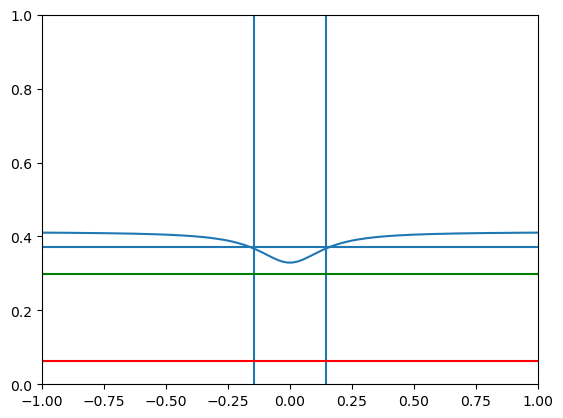

In [68]:
source = CobaltRhodium()
source.Gamma_ev = 9e-9
source.update_params()

absorber = KFeCy()
absorber.Gamma_ev = 5e-9
#absorber.thickness_m = 700e-9  # thickness in m
#absorber.abundance = 0.25
#absorber.Eres = [0]
#absorber.split_ratio = [1]
absorber.update_params()

moss = Mossbauer(source, absorber)

v = np.linspace(-10,10,1000)
t = moss.total_transmission_rate1(v)
norm = moss.source.mossbauer_photon_rate


plt.plot(v, t/norm, label = 'Fe')

plt.axhline((1-((t.max()-t.min())/2/t.max()))*moss.non_resonant_attenuation())
plt.axvline(-(source.Gamma + absorber.Gamma)/2)
plt.axvline((source.Gamma + absorber.Gamma)/2)

plt.axhline((1 - source.fs)*moss.non_resonant_attenuation(),color = 'r')
plt.axhline((1 - source.fs*moss.epsilon(absorber.thickness_normalized))*moss.non_resonant_attenuation(),color = 'g')



plt.ylim(0,1)
plt.xlim(-1,1)

total_width = np.sqrt(absorber.Gamma**2+source.Gamma**2)

B = 0.5
vis = moss.epsilon(absorber.thickness_normalized)*source.fs*(1-B)
vis, (t.max()-t.min())/(t.max())*(1-B), source.mossbauer_photon_rate/1e6, moss.non_resonant_attenuation(), total_width


In [65]:
moss.epsilon(absorber.thickness_normalized)

0.6391381365131534

In [34]:
moss.absorber.Gamma

0.09479166666666666

In [29]:
1e6/3600/24

11.574074074074074

In [32]:
0.19*1.2, 0.23*1.2

(0.22799999999999998, 0.276)